In [52]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PANEL = ROOT / 'data' / 'processed' / 'ohlcv_long.parquet'
UNI   = ROOT / 'data' / 'universe' / 'sp500_pit.parquet'

df = pd.read_parquet(PANEL)
uni = pd.read_parquet(UNI)
print(df.shape, '|', df['ticker'].nunique(), 'tickers |',
      df['date'].min().date(), '→', df['date'].max().date())
df.head()
nassets = df.ticker.nunique()

(3681710, 8) | 682 tickers | 2000-01-03 → 2026-04-21


In [53]:
def format_data(df, target_col: str, index_col: str = 'date', ticker_col: str = 'ticker'):
    return df.set_index([index_col, ticker_col])[target_col].unstack(level=ticker_col)

def oc_format_data(df, index_col: str = 'date', ticker_col: str = 'ticker'):
    open = format_data(df=df, target_col='open', index_col=index_col, ticker_col=ticker_col)
    close = format_data(df=df, target_col='close', index_col=index_col, ticker_col=ticker_col)
    return open, close

In [54]:
open, close = oc_format_data(df)
open = open.ffill(limit = 2).fillna(0)
close = close.ffill(limit = 2).fillna(0)

In [55]:
day_ret = (close/open - 1).replace([np.inf, -np.inf], np.nan).fillna(0)
ovn_ret = (open/close.shift(1) - 1).replace([np.inf, -np.inf], np.nan).fillna(0)

In [62]:
period = 300
mean_ovn = ovn_ret.ewm(span=period, min_periods=1).mean()
std_ovn = ovn_ret.ewm(span=period, min_periods=1).std()
zscore = (ovn_ret - mean_ovn)/std_ovn

alpha = zscore.shift(1).fillna(0)
thold = 2
alpha[alpha >= thold] = thold
alpha[alpha <= -thold] = -thold
alpha[(alpha <= -thold) * (alpha >= thold)] = 0
alpha /= thold
#alpha = alpha.div(alpha.abs().sum(axis = 1), axis = 0).replace([np.inf, -np.inf], np.nan).fillna(0)

def normalise(alpha):
    nassets = len(alpha.columns)
    return alpha / nassets

<Axes: xlabel='date'>

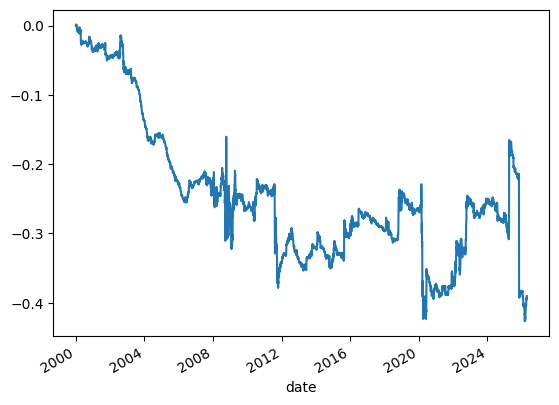

In [63]:
rets = normalise(alpha).mul(day_ret).cumsum(axis=0).sum(axis = 1)
rets.plot()

In [64]:
def market_neutral(alpha: pd.DataFrame):
    long_alpha = alpha[alpha >= 0].fillna(0)
    total_long = long_alpha.sum(axis = 1).replace(0, 1)
    short_alpha = alpha[alpha < 0]
    total_short = short_alpha.abs().sum(axis=1).replace(0, 1)
    
    weights = alpha.copy()
    weights[weights >= 0] = weights[weights >= 0].div(total_long, axis=0)
    weights[weights < 0] = weights[weights < 0].div(total_short, axis=0)
    return weights

In [65]:
alpha_mkn = market_neutral(alpha)

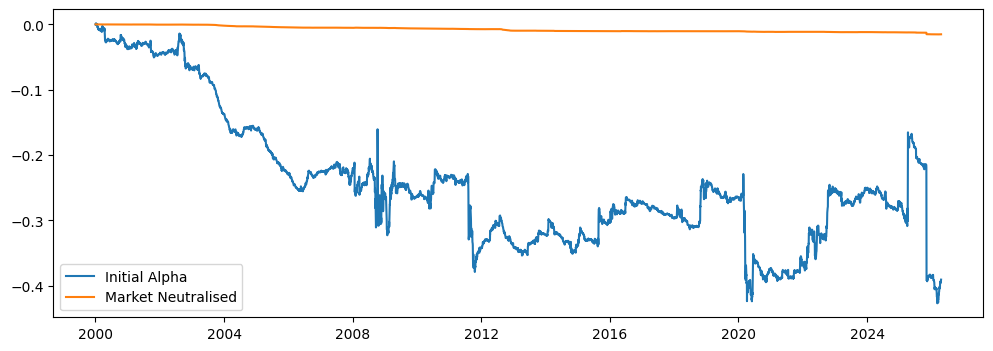

In [68]:
rets_raw = normalise(alpha).mul(day_ret).cumsum(axis=0).sum(axis = 1)
rets_mkn = normalise(alpha_mkn).mul(day_ret).cumsum(axis=0).sum(axis = 1)

fig, ax = plt.subplots(figsize = (12, 4))
ax.plot(rets_raw, label = "Initial Alpha")
ax.plot(rets_mkn, label = "Market Neutralised")
ax.legend()
